In [130]:
import pandas as pd
import numpy as np
from pathlib import Path
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

## Read and process files

In [112]:
files = glob.glob("..\\output\\simulation_results\\step_down_power_dist_response\\*.csv")

In [113]:
df1 = pd.read_csv(files[1], index_col=0)
df1.head()

,Idc,Pac,Vdc_ref,Vdc
TIME,,,,
0.0000,7.495302e-07,3.310638e-47,640.0,0.000000
0.0001,3.321289e-05,-2.553722e-01,640.0,0.000011
0.0002,1.156714e-04,-9.354986e-01,640.0,0.000152
0.0003,2.476955e-04,-2.032740e+00,640.0,0.000985
0.0004,4.289770e-04,-3.544540e+00,640.0,0.003822


In [114]:

def check_power_step_down_voltage_violations(
    res_df: pd.DataFrame,
    u_ref: float,
    file_path : str
):
    """
    Calculate voltage response metrics from a simulation result.

    Parameters
    ----------
    res_df : pd.DataFrame
        Simulation results DataFrame containing the DC voltage column.
    u_ref : float
        Reference DC voltage after the step.
    file_path : str
        Result file path used to extract grid parameters.

    Returns
    -------
    Xm : float
        Maximum voltage deviation above the reference.
    result_df : pd.DataFrame
        DataFrame with extracted grid parameters added.
    """

    STEP_START = 30000
    STEADY_STATE_START = 48000

    result_df = res_df.copy()

    # Extract grid parameters from filename
    file_name = Path(file_path).stem
    parts = file_name.split("_")

    result_df["R_ohms"] = float(parts[-2][1:])
    result_df["H_mH"] = float(parts[-4][1:])
    result_df["C_uF"] = float(parts[-3][1:])

    voltage = result_df["Vdc"]


    # Maximum overshoot after the step
    post_step = voltage.iloc[STEP_START:]
    min_voltage = post_step.min()
    Vdc = voltage.iloc[STEADY_STATE_START:].mean()

    Xm = round(u_ref - min_voltage , 3)
    Xm_index = result_df[result_df['Vdc'] == result_df.iloc[30000:, 3].min()].index[0]

    return Xm, Xm_index, Vdc, result_df


## Visualise response

In [115]:
Xm, Xm_index, Vdc, result_df = check_power_step_down_voltage_violations(df, 640.0, files[1])

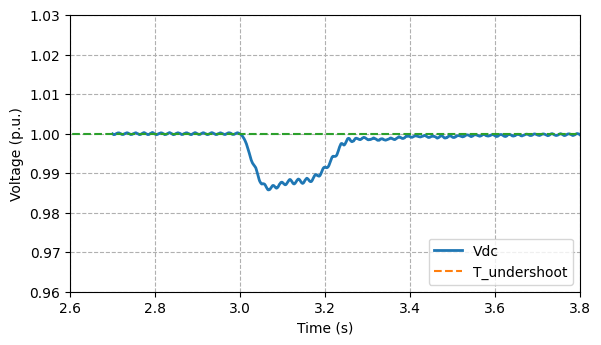

In [116]:
fig, ax = plt.subplots(figsize=(6, 3.5))
df = df1.copy()/640
df.iloc[27000:38000]['Vdc'].plot(ax=ax, linewidth=2, label="Vdc")
ax.plot([Xm_index,Xm_index], [0.95,1.03], linestyle='--', label="T_undershoot")
ax.plot([2.5,4], [1.0,1.0], linestyle='--')   # reference
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_ylabel("Voltage (p.u.)")
ax.set_xlabel("Time (s)")
plt.grid(linestyle="--")
plt.legend(loc=4)
plt.tight_layout()
plt.ylim([0.96, 1.03])
plt.xlim([2.6, 3.8])
output_file = Path("summary/step_up_p_dist.jpg")
output_file.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_file, dpi=300, bbox_inches="tight")


### Run test for power step down simulation

In [117]:
csv_files = glob.glob("..\\output\\simulation_results\\step_down_power_dist_response\\*.csv")
uref = 640
result_summary = []
for file in csv_files:
    file_df = pd.read_csv(file, index_col=0)
    test_var = 1
    try:
        Xm, Xm_index, Vdc, result_df = check_power_step_down_voltage_violations(file_df, uref, file)
    except IndexError:
        print(file)
        continue
    if Xm > 0.05*uref:
        test_var = 0
    result_df["Xm"] = Xm
    result_df["Vdc_ss_mean"] = round(Vdc,3)
    result_df["score"] = test_var
    result_summary.append(pd.DataFrame([result_df.iloc[-1,:]]))
result_summary_df1 = pd.concat(result_summary, axis=0).reset_index(drop=True)

output_file = Path("summary\\step_up_u_dist_response_summary.csv")
output_file.parent.mkdir(parents=True, exist_ok=True)
result_summary_df1.rename(columns={"Idc": "Idc_final", "Pac": "Pac_final"}, inplace=True)
result_summary_df1.drop(columns=["Vdc"], inplace=True)
result_summary_df1.to_csv(output_file, index=True)

In [118]:
result_summary_df1.head()

,Idc_final,Pac_final,Vdc_ref,R_ohms,H_mH,C_uF,Xm,Vdc_ss_mean,score
0,0.922661,591.665897,640.0,10.0,400.0,1000.0,7.650,640.000,1.0
1,0.928380,594.434431,640.0,6.0,400.0,1000.0,9.118,639.999,1.0
2,0.927041,593.808876,640.0,7.0,400.0,1000.0,8.718,639.999,1.0
3,0.925885,592.706488,640.0,8.0,400.0,1000.0,8.343,639.999,1.0
4,0.924530,592.017138,640.0,9.0,400.0,1000.0,7.989,639.999,1.0


In [119]:
result_summary_df1[result_summary_df1['score']==1].shape

(350, 9)

In [120]:
result_summary_df.shape

(350, 10)

## Power step up simulaiton

In [121]:

def check_power_step_up_voltage_violations(
    res_df: pd.DataFrame,
    u_ref: float,
    file_path : str
):
    """
    Calculate voltage response metrics from a simulation result.

    Parameters
    ----------
    res_df : pd.DataFrame
        Simulation results DataFrame containing the DC voltage column.
    u_ref : float
        Reference DC voltage after the step.
    file_path : str
        Result file path used to extract grid parameters.

    Returns
    -------
    Xm : float
        Maximum voltage deviation above the reference.
    result_df : pd.DataFrame
        DataFrame with extracted grid parameters added.
    """

    STEP_START = 30000
    STEADY_STATE_START = 48000

    result_df = res_df.copy()

    # Extract grid parameters from filename
    file_name = Path(file_path).stem
    parts = file_name.split("_")

    result_df["R_ohms"] = float(parts[-2][1:])
    result_df["H_mH"] = float(parts[-4][1:])
    result_df["C_uF"] = float(parts[-3][1:])

    voltage = result_df["Vdc"]


    # Maximum overshoot after the step
    post_step = voltage.iloc[STEP_START:]
    max_voltage = post_step.max()
    Vdc = voltage.iloc[STEADY_STATE_START:].mean()

    Xm = round(max_voltage - uref, 3)
    Xm_index = result_df[result_df['Vdc'] == result_df.iloc[30000:, 3].min()].index[0]

    return Xm, Xm_index, Vdc, result_df


## Visualise response

In [122]:
P_step_down_files = glob.glob("..\\output\\simulation_results\\step_up_power_dist_response\\*.csv")
df2 = pd.read_csv(P_step_down_files[0], index_col=0)
df2.head()

,Idc,Pac,Vdc_ref,Vdc
TIME,,,,
0.0000,7.494678e-07,2.830501e-47,640.0,0.000000
0.0001,3.319998e-05,-2.553722e-01,640.0,0.000011
0.0002,1.155881e-04,-9.354986e-01,640.0,0.000152
0.0003,2.474351e-04,-2.032740e+00,640.0,0.000985
0.0004,4.283836e-04,-3.544540e+00,640.0,0.003821


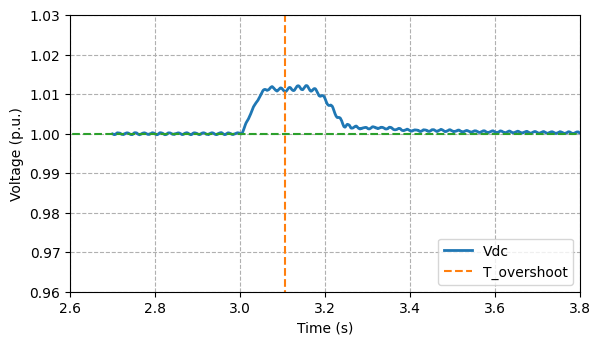

In [123]:
fig, ax = plt.subplots(figsize=(6, 3.5))
df = df2.copy()/640
df.iloc[27000:38000]['Vdc'].plot(ax=ax, linewidth=2, label="Vdc")
ax.plot([Xm_index,Xm_index], [0.95,1.03], linestyle='--', label="T_overshoot")
ax.plot([2.5,4], [1.0,1.0], linestyle='--')   # reference
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_ylabel("Voltage (p.u.)")
ax.set_xlabel("Time (s)")
plt.grid(linestyle="--")
plt.legend(loc=4)
plt.tight_layout()
plt.ylim([0.96, 1.03])
plt.xlim([2.6, 3.8])

output_file = Path("summary/step_down_p_dist.jpg")
output_file.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_file, dpi=300, bbox_inches="tight")

## Run test

In [124]:
csv_files = glob.glob("..\\output\\simulation_results\\step_up_power_dist_response\\*.csv")
uref = 640
result_summary = []
for file in csv_files:
    file_df = pd.read_csv(file, index_col=0)
    test_var = 1
    try:
        Xm, Xm_index, Vdc, result_df = check_power_step_up_voltage_violations(file_df, uref, file)
    except IndexError:
        print(file)
        continue
    if Xm > 0.05*uref:
        test_var = 0
    result_df["Xm"] = Xm
    result_df["Vdc_ss_mean"] = round(Vdc,3)
    result_df["score"] = test_var
    result_summary.append(pd.DataFrame([result_df.iloc[-1,:]]))
    
result_summary_df2 = pd.concat(result_summary, axis=0).reset_index(drop=True)
output_file = Path("summary\\step_up_u_dist_response_summary.csv")
output_file.parent.mkdir(parents=True, exist_ok=True)
result_summary_df2.rename(columns={"Idc": "Idc_final", "Pac": "Pac_final"}, inplace=True)
result_summary_df2.drop(columns=["Vdc"], inplace=True)
result_summary_df2.to_csv(output_file, index=True)

In [125]:
result_summary_df2.head()

,Idc_final,Pac_final,Vdc_ref,R_ohms,H_mH,C_uF,Xm,Vdc_ss_mean,score
0,1.525193,974.382949,640.0,10.0,400.0,1000.0,7.779,640.001,1.0
1,1.539400,983.244614,640.0,6.0,400.0,1000.0,8.943,640.001,1.0
2,1.535614,981.281134,640.0,7.0,400.0,1000.0,8.582,640.001,1.0
3,1.532107,978.964937,640.0,8.0,400.0,1000.0,8.244,640.001,1.0
4,1.528621,976.683788,640.0,9.0,400.0,1000.0,7.901,640.001,1.0


In [126]:
result_summary_df2[result_summary_df2['score']==1].shape

(350, 9)

## Visualisation summary

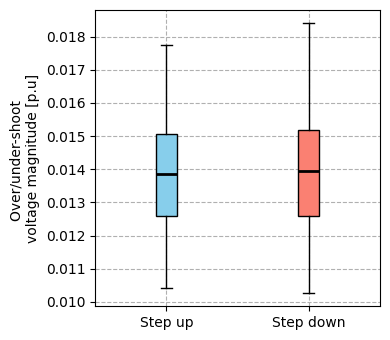

In [128]:
fig, ax = plt.subplots(figsize=(4, 3.5))

bp = ax.boxplot(
     [result_summary_df2["Xm"]/640,
     result_summary_df1["Xm"]/640],
     tick_labels=["Step up", "Step down"],
     patch_artist=True 
)
colors = ["skyblue", "salmon"]
for box, color in zip(bp["boxes"], colors):
    box.set(facecolor=color)

for median in bp["medians"]:
    median.set(color="black", linewidth=2) 
    
ax.set_ylabel("Over/under-shoot \nvoltage magnitude [p.u]")
ax.grid(linestyle="--")

plt.tight_layout()
output_file = Path("summary\\step_power_dist_plot.pdf")
output_file.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_file)